# ❤️ Heart Disease Prediction using Machine Learning

### End-to-End Machine Learning Project

**Author:** Sandeep Vyas

**Tools Used:** Python, Pandas, NumPy, Matplotlib, Seaborn, Scikit-learn

**Project Type:** Binary Classification

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression

from sklearn.svm import SVC

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [2]:
df = pd.read_csv("heart.csv")

In [35]:
df.shape

(283, 16)

In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 283 entries, 0 to 878
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   age            283 non-null    int64  
 1   sex            283 non-null    int64  
 2   cp             283 non-null    int64  
 3   trestbps       283 non-null    int64  
 4   chol           283 non-null    int64  
 5   fbs            283 non-null    int64  
 6   restecg        283 non-null    int64  
 7   thalach        283 non-null    int64  
 8   exang          283 non-null    int64  
 9   oldpeak        283 non-null    float64
 10  slope          283 non-null    int64  
 11  ca             283 non-null    int64  
 12  thal           283 non-null    int64  
 13  target         283 non-null    int64  
 14  bp_chol_ratio  283 non-null    float64
 15  heart_score    283 non-null    float64
dtypes: float64(3), int64(13)
memory usage: 37.6 KB


In [37]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,bp_chol_ratio,heart_score
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0,0.589623,3.0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0,0.689655,3.1
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0,0.833333,2.6
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0,0.729064,1.0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0,0.469388,4.9


In [7]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [8]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(723)

In [10]:
df[df.duplicated()]

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
15,34,0,1,118,210,0,1,192,0,0.7,2,0,2,1
31,50,0,1,120,244,0,1,162,0,1.1,2,0,2,1
43,46,1,0,120,249,0,0,144,0,0.8,2,0,3,0
55,55,1,0,140,217,0,1,111,1,5.6,0,0,3,0
61,66,0,2,146,278,0,0,152,0,0.0,1,1,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1


In [11]:
df = df.drop_duplicates()

In [12]:
df.shape

(302, 14)

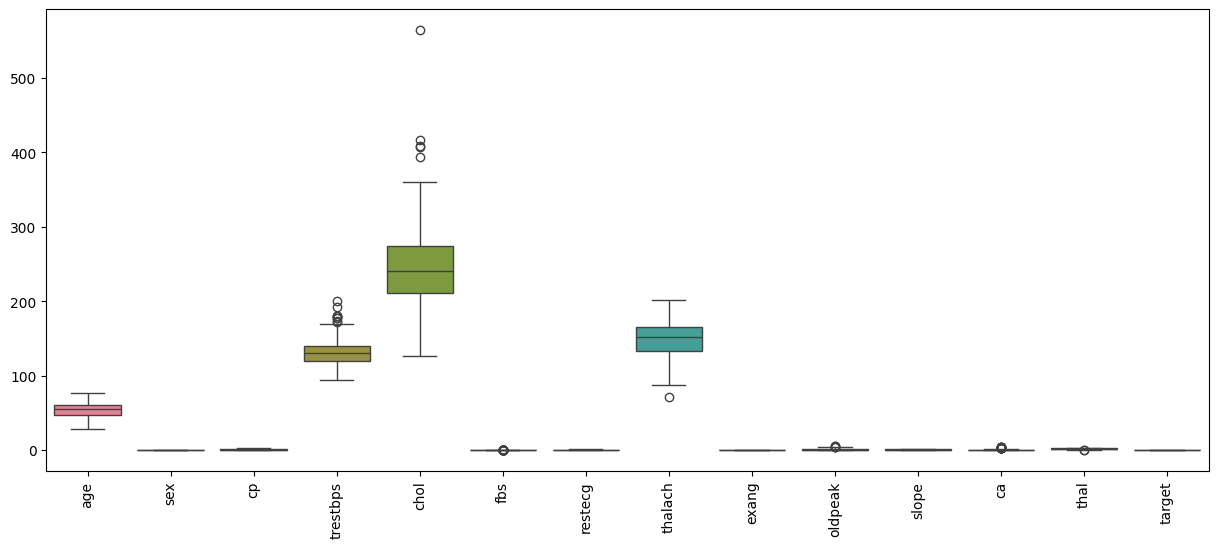

In [13]:
plt.figure(figsize=(15,6))
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.show()

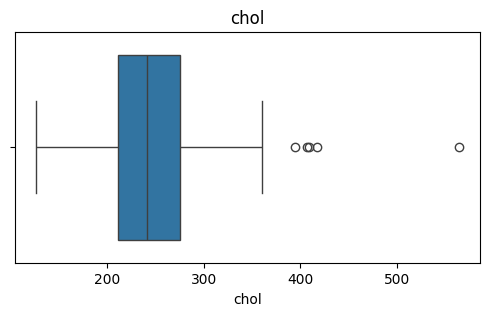

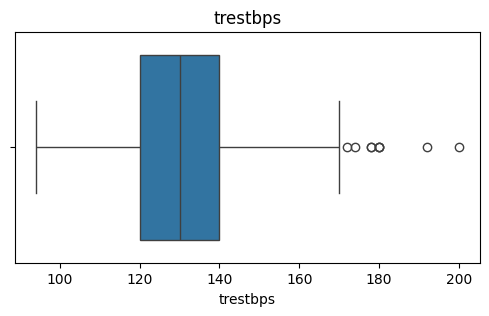

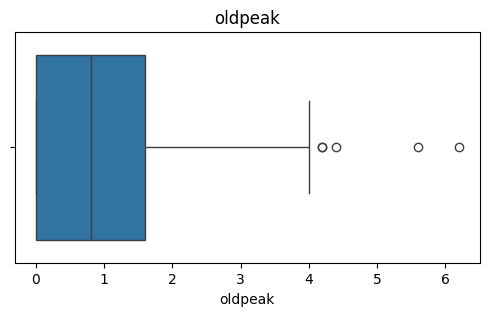

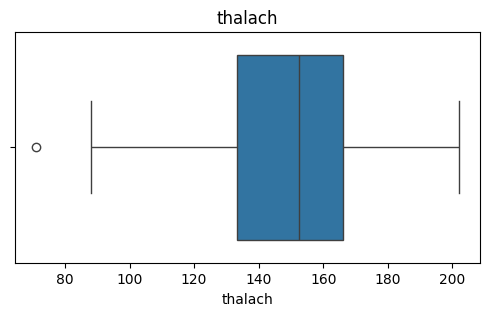

In [14]:
columns = ["chol", "trestbps", "oldpeak", "thalach"]

for col in columns:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

In [15]:
Q1 = df["chol"].quantile(0.25)
Q3 = df["chol"].quantile(0.75)
IQR = Q3 - Q1

In [16]:
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

In [17]:
df = df[(df["chol"] >= lower_limit) & (df["chol"] <= upper_limit)]

In [18]:
df.shape

(297, 14)

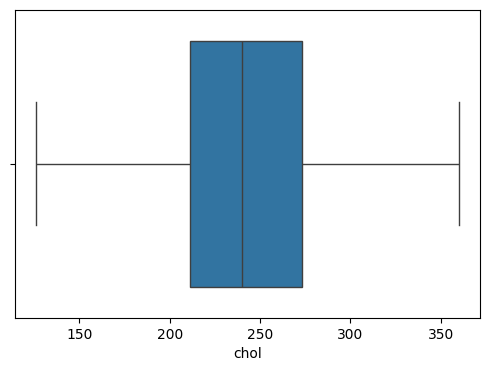

In [19]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df["chol"])
plt.show()

In [20]:
columns = ["chol", "trestbps", "oldpeak", "thalach"]

for col in columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    df = df[(df[col] >= lower_limit) & (df[col] <= upper_limit)]

In [21]:
df.shape

(283, 14)

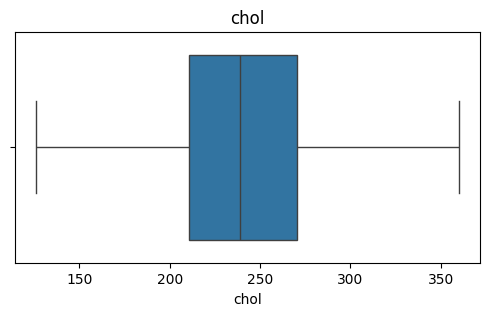

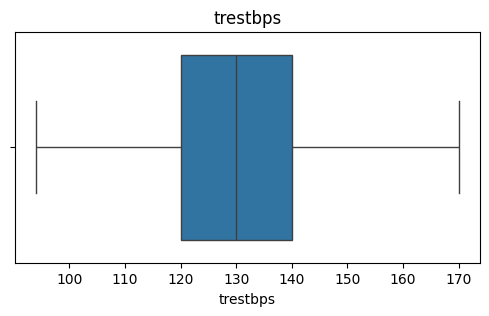

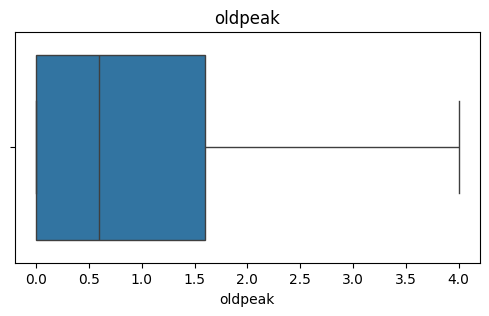

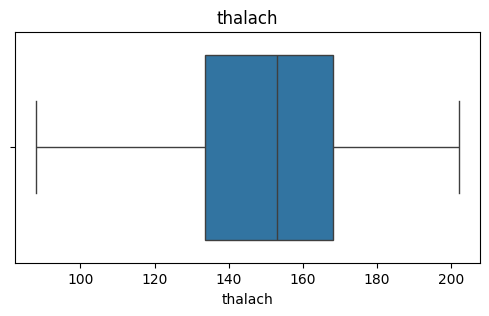

In [22]:
columns = ["chol", "trestbps", "oldpeak", "thalach"]

for col in columns:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

In [23]:
df["bp_chol_ratio"] = df["trestbps"] / df["chol"]

In [24]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,bp_chol_ratio
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0,0.589623
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0,0.689655
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0,0.833333
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0,0.729064
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0,0.469388


In [25]:
df["heart_score"] = df["oldpeak"] + df["ca"]

In [26]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,bp_chol_ratio,heart_score
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0,0.589623,3.0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0,0.689655,3.1
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0,0.833333,2.6
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0,0.729064,1.0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0,0.469388,4.9


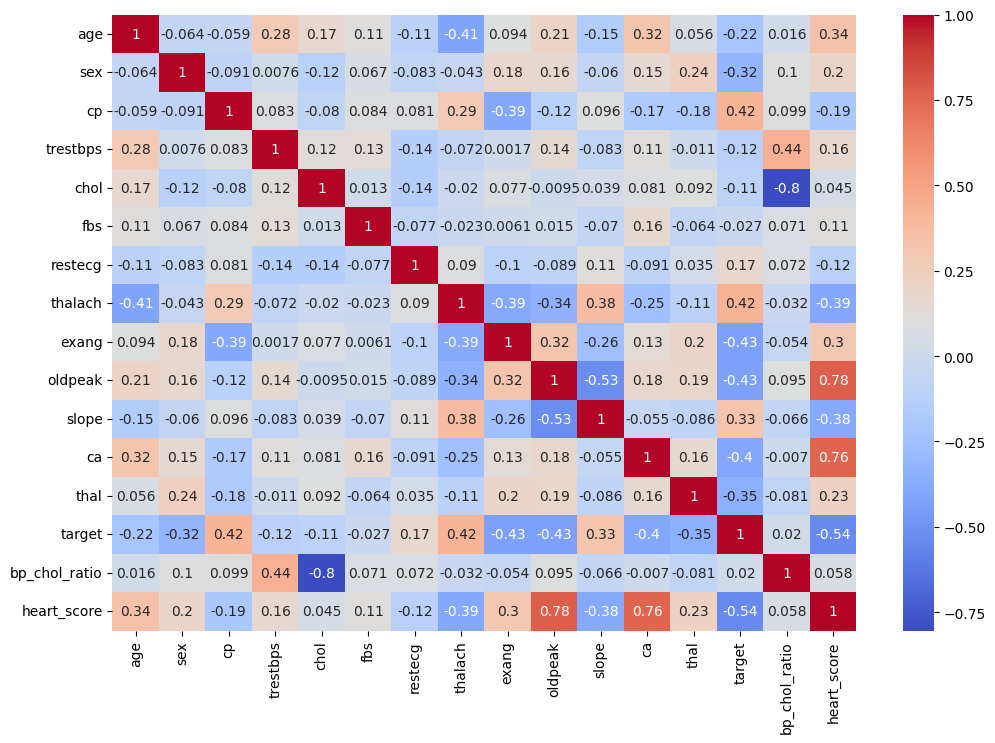

In [27]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.show()

In [28]:
selected_features = ["cp","thalach","oldpeak","ca","slope","thal","heart_score","target"]

In [29]:
df_selected = df[selected_features]

In [30]:
df_selected.head()

,cp,thalach,oldpeak,ca,slope,thal,heart_score,target
0,0,168,1.0,2,2,3,3.0,0
1,0,155,3.1,0,0,3,3.1,0
2,0,125,2.6,0,0,3,2.6,0
3,0,161,0.0,1,2,3,1.0,0
4,0,106,1.9,3,1,2,4.9,0


In [31]:
df_selected.duplicated().sum()

np.int64(11)

In [32]:
df_selected.dtypes

cp               int64
thalach          int64
oldpeak        float64
ca               int64
slope            int64
thal             int64
heart_score    float64
target           int64
dtype: object

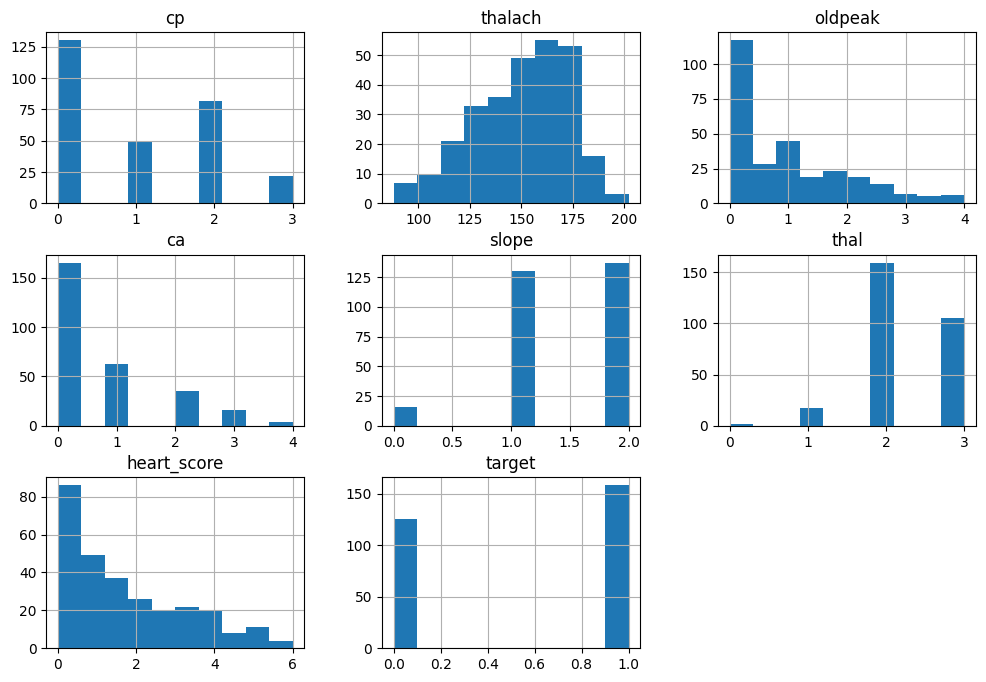

In [33]:
df_selected.hist(figsize=(12,8))
plt.show()

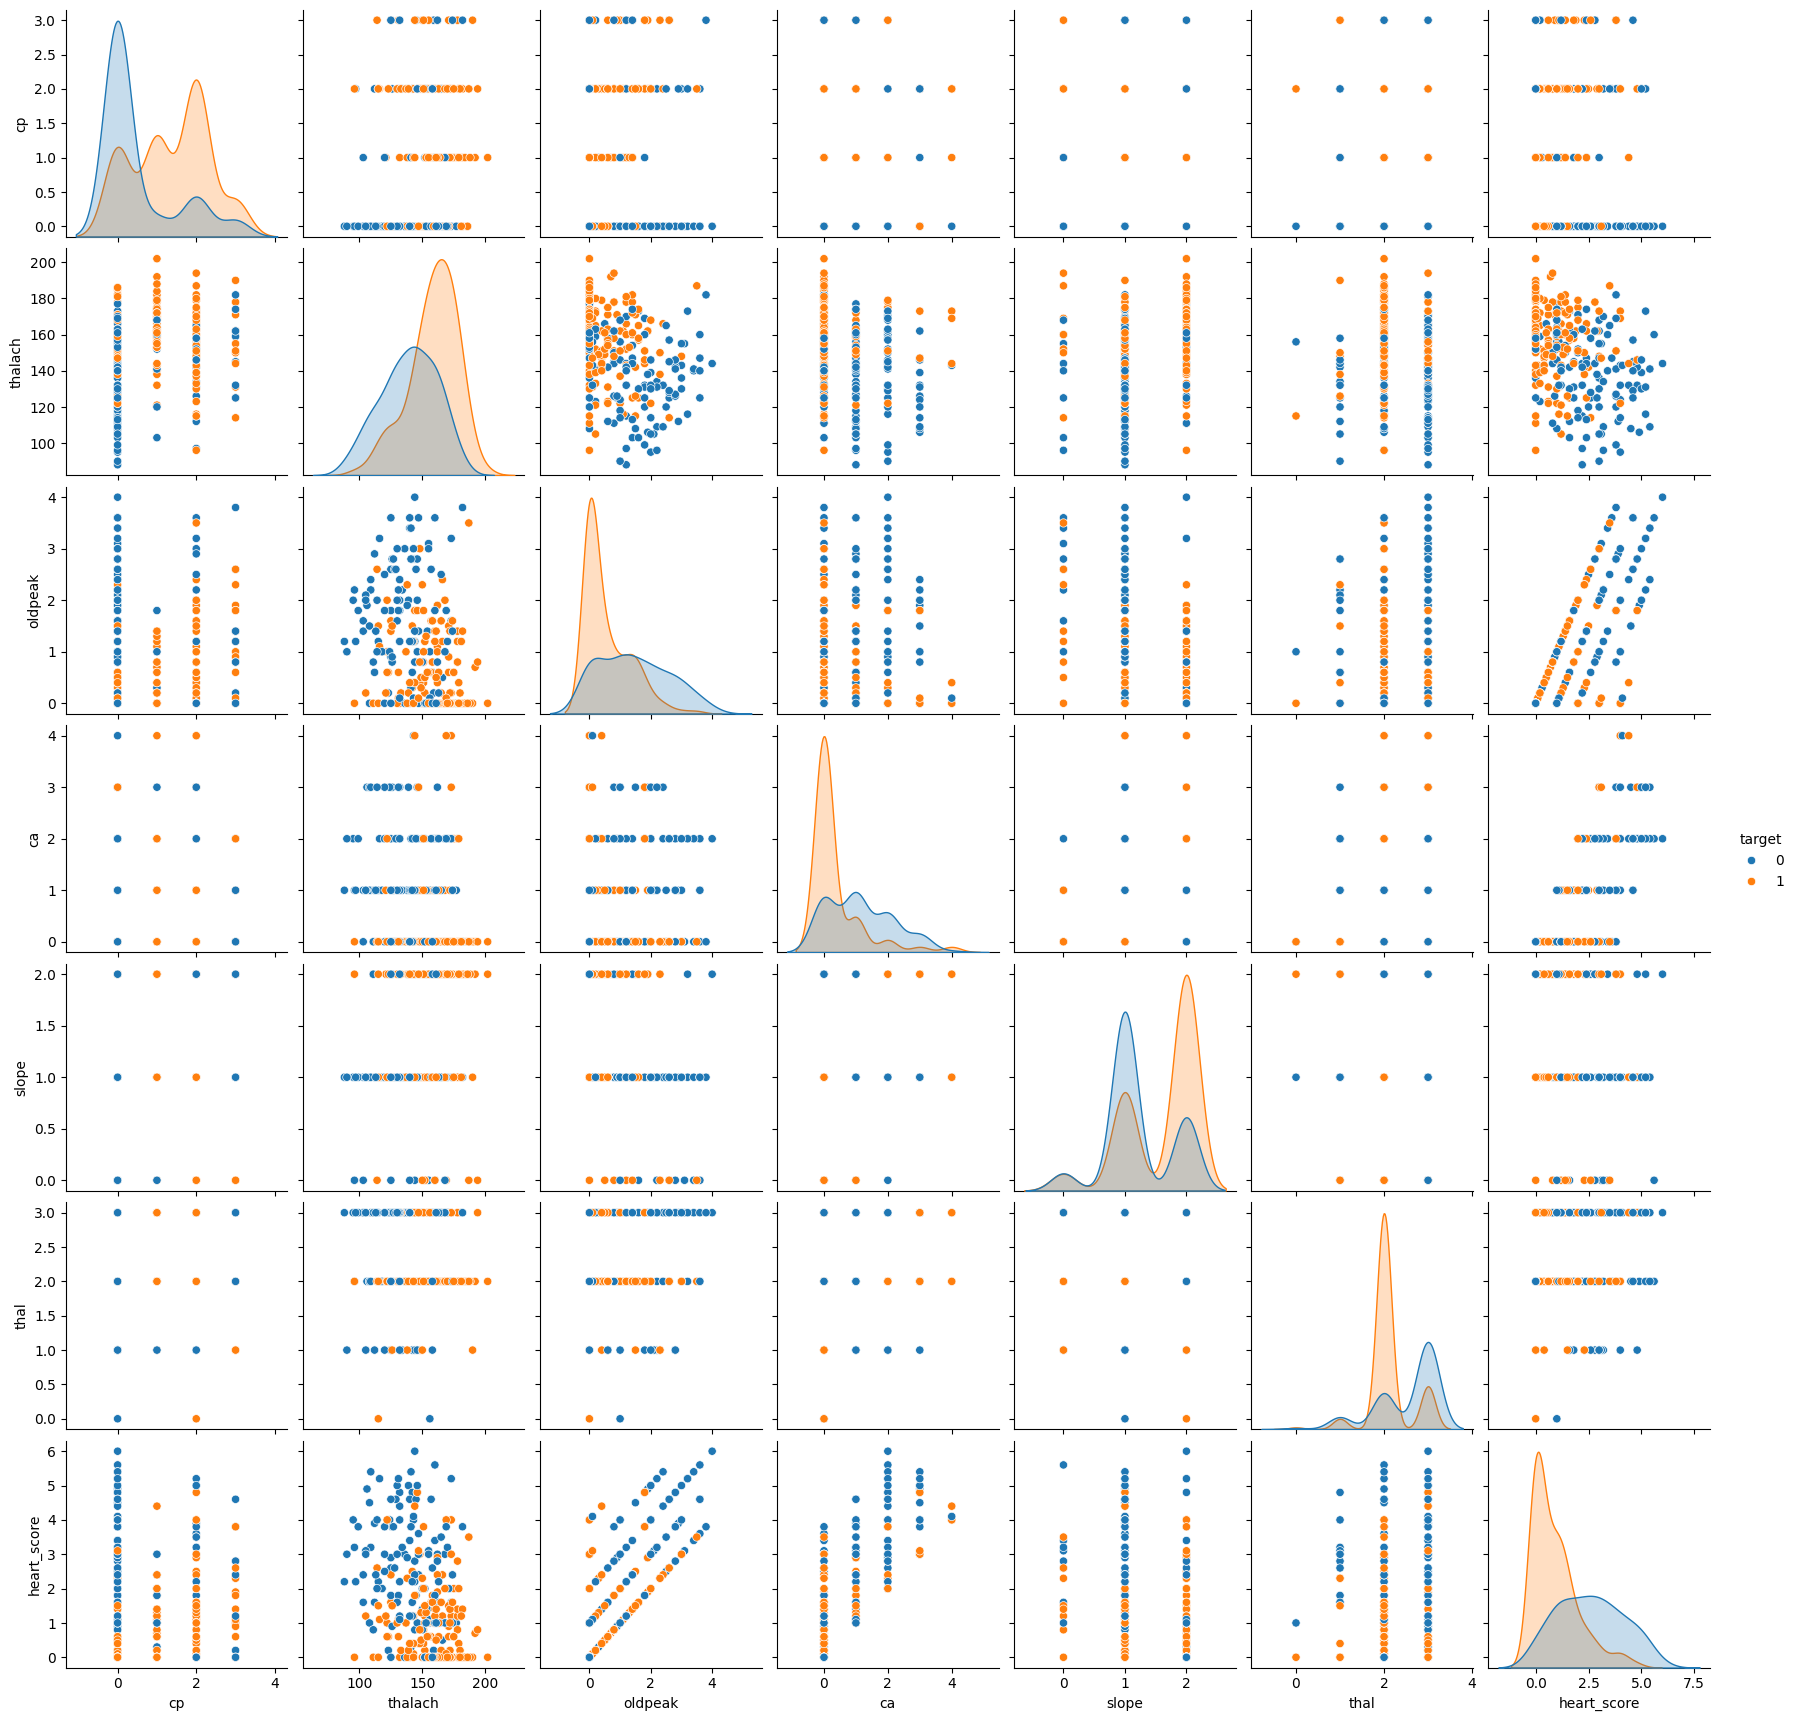

In [34]:
sns.pairplot(df_selected, hue="target")
plt.show()

# Machine Learning Model Building

In [39]:
X=df_selected.drop("target",axis=1)
y=df_selected["target"]

In [41]:
X.head()


,cp,thalach,oldpeak,ca,slope,thal,heart_score
0,0,168,1.0,2,2,3,3.0
1,0,155,3.1,0,0,3,3.1
2,0,125,2.6,0,0,3,2.6
3,0,161,0.0,1,2,3,1.0
4,0,106,1.9,3,1,2,4.9


y.head()

In [44]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [45]:
print("X_train Shape :", X_train.shape)
print("X_test Shape  :", X_test.shape)
print("y_train Shape :", y_train.shape)
print("y_test Shape  :", y_test.shape)

X_train Shape : (226, 7)
X_test Shape  : (57, 7)
y_train Shape : (226,)
y_test Shape  : (57,)


# Feature Scaling (Standardization)

In [51]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [52]:
X_train

array([[-0.98771593, -1.71736134, -0.33945177, ..., -0.68515752,
        -2.0816495 , -0.01161865],
       [ 0.9533606 , -0.39496385, -0.33945177, ..., -0.68515752,
        -2.0816495 , -0.01161865],
       [-0.01717767, -2.11408058,  0.41730384, ..., -0.68515752,
         1.16285248,  0.50073536],
       ...,
       [-0.98771593, -0.65944335, -0.90701847, ..., -0.68515752,
        -0.45939851, -1.03632665],
       [-0.98771593, -1.14432243,  2.49838174, ..., -0.68515752,
        -0.45939851,  1.90970886],
       [ 0.9533606 , -0.08640444, -0.43404622, ...,  0.94479616,
        -0.45939851, -0.7161054 ]], shape=(226, 7))

# Logistic Regression Model

In [54]:
model = LogisticRegression()
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [55]:
y_pred = model.predict(X_test)

In [58]:
print("Accuracy :", accuracy_score(y_test, y_pred))

Accuracy : 0.8070175438596491


## Confusion Matrix

In [59]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[21  5]
 [ 6 25]]


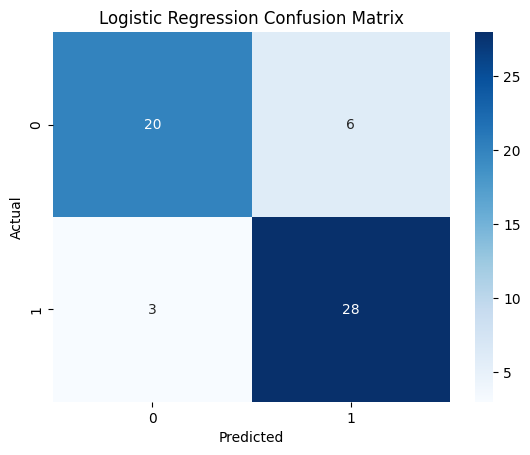

In [89]:
sns.heatmap(cm,annot=True,fmt="d",cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")
plt.show()

# Precision, Recall and F1 Score

In [61]:
print("Precision :", precision_score(y_test, y_pred))

print("Recall :", recall_score(y_test, y_pred))

print("F1 Score :", f1_score(y_test, y_pred))

Precision : 0.8333333333333334
Recall : 0.8064516129032258
F1 Score : 0.819672131147541


In [62]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.78      0.81      0.79        26
           1       0.83      0.81      0.82        31

    accuracy                           0.81        57
   macro avg       0.81      0.81      0.81        57
weighted avg       0.81      0.81      0.81        57



## Support Vector Machine (SVC) Model

In [63]:
svc_model = SVC()
svc_model.fit(X_train, y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [64]:
y_pred_svc = svc_model.predict(X_test)

In [65]:
print("Accuracy :", accuracy_score(y_test, y_pred_svc))

Accuracy : 0.8245614035087719


## Confusion Matrix

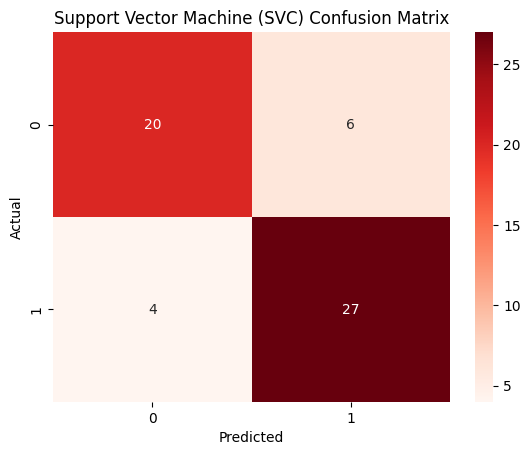

In [90]:
cm = confusion_matrix(y_test, y_pred_svc)

sns.heatmap(cm,annot=True,cmap="Reds",fmt="d")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Support Vector Machine (SVC) Confusion Matrix")
plt.show()

## Precision, Recall and F1 Score

In [67]:
print("Precision :", precision_score(y_test, y_pred_svc))

print("Recall :", recall_score(y_test, y_pred_svc))

print("F1 Score :", f1_score(y_test, y_pred_svc))

Precision : 0.8181818181818182
Recall : 0.8709677419354839
F1 Score : 0.84375


In [68]:
print(classification_report(y_test, y_pred_svc))

              precision    recall  f1-score   support

           0       0.83      0.77      0.80        26
           1       0.82      0.87      0.84        31

    accuracy                           0.82        57
   macro avg       0.83      0.82      0.82        57
weighted avg       0.83      0.82      0.82        57



# Decision Tree Classifier

In [69]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [70]:
y_pred_dt = dt_model.predict(X_test)

In [71]:
print("Accuracy :", accuracy_score(y_test, y_pred_dt))

Accuracy : 0.6842105263157895


## Confusion Matrix

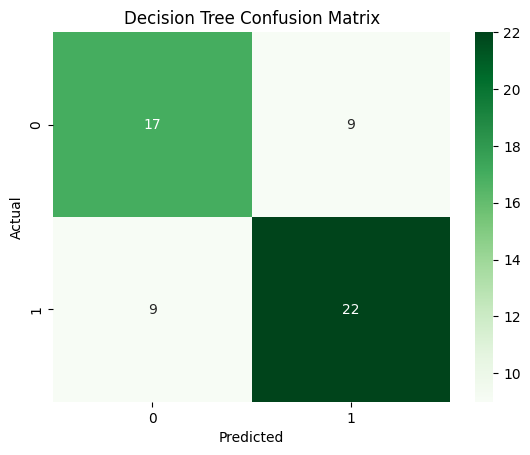

In [72]:
cm = confusion_matrix(y_test, y_pred_dt)

sns.heatmap(cm,annot=True,cmap="Greens",fmt="d")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Decision Tree Confusion Matrix")
plt.show()

## Precision, Recall, and F1 Score

In [75]:
print("Precision :", precision_score(y_test, y_pred_dt))

print("Recall :", recall_score(y_test, y_pred_dt))

print("F1 Score :", f1_score(y_test, y_pred_dt))

Precision : 0.7096774193548387
Recall : 0.7096774193548387
F1 Score : 0.7096774193548387


In [76]:
print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       0.65      0.65      0.65        26
           1       0.71      0.71      0.71        31

    accuracy                           0.68        57
   macro avg       0.68      0.68      0.68        57
weighted avg       0.68      0.68      0.68        57



# Random Forest Classifier

In [77]:
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [78]:
y_pred_rf = rf_model.predict(X_test)

In [79]:
print("Accuracy :", accuracy_score(y_test, y_pred_rf))

Accuracy : 0.8421052631578947


## Confusion Matrix

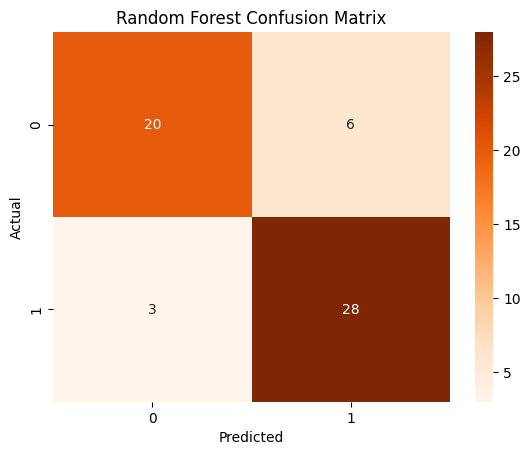

In [81]:
cm = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm,annot=True,cmap="Oranges",fmt="d")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")
plt.show()

## Precision, Recall, and F1 Score

In [82]:
print("Precision :", precision_score(y_test, y_pred_rf))

print("Recall :", recall_score(y_test, y_pred_rf))

print("F1 Score :", f1_score(y_test, y_pred_rf))

Precision : 0.8235294117647058
Recall : 0.9032258064516129
F1 Score : 0.8615384615384616


In [83]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.87      0.77      0.82        26
           1       0.82      0.90      0.86        31

    accuracy                           0.84        57
   macro avg       0.85      0.84      0.84        57
weighted avg       0.84      0.84      0.84        57



# Model Comparison

In [84]:
comparison = pd.DataFrame({"Model":["Logistic Regression","Support Vector Machine","Decision Tree","Random Forest"],

    "Accuracy":[
        accuracy_score(y_test,y_pred),
        accuracy_score(y_test,y_pred_svc),
        accuracy_score(y_test,y_pred_dt),
        accuracy_score(y_test,y_pred_rf)],

    "Precision":[
        precision_score(y_test,y_pred),
        precision_score(y_test,y_pred_svc),
        precision_score(y_test,y_pred_dt),
        precision_score(y_test,y_pred_rf)],

    "Recall":[
        recall_score(y_test,y_pred),
        recall_score(y_test,y_pred_svc),
        recall_score(y_test,y_pred_dt),
        recall_score(y_test,y_pred_rf)],

    "F1 Score":[
        f1_score(y_test,y_pred),
        f1_score(y_test,y_pred_svc),
        f1_score(y_test,y_pred_dt),
        f1_score(y_test,y_pred_rf)]})

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.807018,0.833333,0.806452,0.819672
1,Support Vector Machine,0.824561,0.818182,0.870968,0.843750
2,Decision Tree,0.684211,0.709677,0.709677,0.709677
3,Random Forest,0.842105,0.823529,0.903226,0.861538


# Best Model Selection

In [87]:
comparison.sort_values(by="Accuracy",ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score
3,Random Forest,0.842105,0.823529,0.903226,0.861538
1,Support Vector Machine,0.824561,0.818182,0.870968,0.843750
0,Logistic Regression,0.807018,0.833333,0.806452,0.819672
2,Decision Tree,0.684211,0.709677,0.709677,0.709677


<div style="background-color:#0F172A;padding:18px;border-radius:12px;">

<h1 align="center" style="color:#60A5FA;">
🫀 Heart Disease Prediction using Machine Learning
</h1>

<h3 align="center" style="color:white;">
End-to-End Machine Learning Project
</h3>

</div>

---

<div style="background:#DCFCE7;padding:12px;border-left:6px solid green;border-radius:8px;">

<h2>🎯 Project Objective</h2>

Build a complete Machine Learning pipeline for Heart Disease Prediction including:

✔ Data Cleaning

✔ Exploratory Data Analysis (EDA)

✔ Feature Engineering

✔ Feature Selection

✔ Machine Learning Model Building

✔ Model Evaluation

</div>

---

# 📂 Project Workflow

## ✅ Data Collection

- Imported Dataset
- Imported Required Libraries

---

## ✅ Data Understanding

- Dataset Shape
- Dataset Information
- Data Types
- First Five Rows
- Statistical Summary

---

## ✅ Data Cleaning

✔ Missing Values Checked

✔ Duplicate Records Removed

✔ Outliers Removed using IQR Method

✔ Data Types Verified

---

## ✅ Exploratory Data Analysis

📊 Histogram

📦 Box Plot

🔥 Correlation Heatmap

📈 Pair Plot

---

## ✅ Feature Engineering

Created New Features:

- bp_chol_ratio
- heart_score

---

## ✅ Feature Selection

Selected Important Features using Correlation Analysis.

---

## ✅ Data Preparation

✔ Train-Test Split

✔ Feature Scaling (StandardScaler)

---

<div style="background:#DBEAFE;padding:12px;border-left:6px solid #2563EB;border-radius:8px;">

<h2>🤖 Machine Learning Models</h2>

✔ Logistic Regression

✔ Support Vector Machine (SVC)

✔ Decision Tree Classifier

✔ Random Forest Classifier

</div>

---

## 📊 Model Evaluation

The following metrics were used:

- Accuracy
- Precision
- Recall
- F1 Score
- Confusion Matrix
- Classification Report

---

## 🏆 Model Comparison

All Machine Learning models were compared using:

✔ Accuracy

✔ Precision

✔ Recall

✔ F1 Score

The best-performing model was selected based on overall performance.

---

<div style="background:#FEF3C7;padding:12px;border-left:6px solid orange;border-radius:8px;">

<h2>🚀 Skills Demonstrated</h2>

Python

NumPy

Pandas

Matplotlib

Seaborn

Scikit-Learn

Data Cleaning

EDA

Feature Engineering

Feature Selection

Machine Learning

Model Evaluation

Model Comparison

</div>

---

<div style="background:#E0F2FE;padding:15px;border-left:6px solid #0284C7;border-radius:8px;">

<h2>🎉 Final Conclusion</h2>

This project demonstrates a complete End-to-End Machine Learning workflow.

The dataset was cleaned, visualized, feature engineered, and multiple Machine Learning models were trained and evaluated.

Finally, all models were compared using Accuracy, Precision, Recall and F1 Score, and the best-performing model was selected for Heart Disease Prediction.

</div>

---

<h2 align="center">
⭐ Thank You ⭐
</h2>